# CTAO IRF productions: differential sensitivity with FEUPY

This tutorial calculates and compares differential sensitivity curves using **CTAO prod5**, **prod6 (dark)**, and **prod6 (halfmoon)** IRFs. It uses `CTAOAnalysisConfig`, `CTAOAnalysis`, and FEUPY sensitivity plotting utilities. Curves are saved as ECSV tables and can be reloaded without rerunning the analysis.

**Prerequisites:** FEUPY, Gammapy, the appropriate IRF files, and valid `required_irfs` selectors. The example does not fabricate sensitivity curves or assume every production/condition is installed.

## 1. Imports and plotting style

In [1]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst
from copy import deepcopy
from pathlib import Path

import astropy.units as u
import feupy
import gammapy
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
from astropy.table import Table
from gammapy.modeling.models import Models, PowerLawSpectralModel, SkyModel
from gammapy.utils.scripts import make_path

from feupy.analysis.config import CTAOAnalysisConfig
from feupy.analysis.core import CTAOAnalysis
from feupy.utils.coordinates import convert_skycoord_to_dict
from feupy.visualization import FEUPY_MPL_STYLE
from feupy.visualization.sensitivity import (
    plot_irfs,
    plot_sensitivity_from_table,
    plot_tables_sensitivity,
)

plt.style.use(make_path(FEUPY_MPL_STYLE))
print("FEUPY:", feupy.__version__)
print("Gammapy:", gammapy.__version__)

FEUPY: 0.1.0
Gammapy: 2.0


## 2. Shared observation settings

The same region, exposure, energy binning, and sensitivity criteria are used for every IRF configuration. The position below is an **illustrative pointing direction**, not a visibility-validated CTAO target. Choose a position compatible with the site and IRFs for a scientific comparison.

In [2]:
# ============================================================
# Observational setup
# ============================================================

SITE = "South"
AZIMUTH = "AverageAz"
ZENITH_DEG = 20

OFFSET = 0.5 * u.deg
LIVETIME = 50 * u.h
ON_RADIUS = 0.11 * u.deg
N_OBS = 1

position = SkyCoord(
    ra=83.6331 * u.deg,
    dec=22.0145 * u.deg,
    frame="icrs",
)


# ============================================================
# IRF configurations
# ============================================================

REQUIRED_IRFS = [
    SITE,
    AZIMUTH,
    f"{ZENITH_DEG}deg",
    "50h",
]

CONFIGURATIONS = {
    "prod5_dark": {
        "production": "prod5",
        "condition": "dark",
    },
    "prod6_dark": {
        "production": "prod6",
        "condition": "dark",
    },
    "prod6_halfmoon": {
        "production": "prod6",
        "condition": "halfmoon",
    },
}


# ============================================================
# Output configuration
# ============================================================

OUTPUT_DIR = Path("../data/sensitivity").resolve()

RUN_SIMULATIONS = True
REUSE_SAVED_TABLES = True

## 3. Reference source model

In [3]:
source_model = SkyModel(
    spectral_model=PowerLawSpectralModel(
        index=2.5,
        amplitude=1e-11 * u.Unit("cm-2 s-1 TeV-1"),
        reference=1 * u.TeV,
    ),
    name="source",
)
source_model

SkyModel(spatial_model=None, spectral_model=<gammapy.modeling.models.spectral.PowerLawSpectralModel object at 0x7e6fda7747a0>)temporal_model=None)

## 4. Construct a FEUPY analysis configuration

`irf_production` and `irf_condition` are set independently. The analysis configuration below follows the FEUPY workflow used in the project.

In [23]:
def make_analysis_config(
    production,
    condition,
    required_irfs=None,
):
    """Create a CTAO analysis configuration."""
    if required_irfs is None:
        required_irfs = REQUIRED_IRFS

    config = CTAOAnalysisConfig()

    config.observation.obs_cone = convert_skycoord_to_dict(position)
    config.observation.position_angle = 0 * u.deg
    config.observation.offset = OFFSET
    config.observation.livetime = LIVETIME

    config.observation.required_irfs = required_irfs
    config.observation.irf_production = production
    config.observation.irf_condition = condition

    config.datasets.map_selection = ["edisp", "background", "exposure"]
    config.datasets.safe_mask.methods = ["aeff-default"]
    config.datasets.safe_mask.parameters = {"aeff_percent": 10}
    config.datasets.containment_correction = False
    config.datasets.use_region_center = True
    config.datasets.on_region = convert_skycoord_to_dict(position)
    config.datasets.on_region.radius = ON_RADIUS
    config.datasets.stack = False
    config.datasets.on_off.acceptance = 1
    config.datasets.on_off.acceptance_off = 5

    config.datasets.geom.axes.energy.min = 30 * u.GeV
    config.datasets.geom.axes.energy.max = 200 * u.TeV
    config.datasets.geom.axes.energy.nbins = 15
    config.datasets.geom.axes.energy_true.min = 3 * u.GeV
    config.datasets.geom.axes.energy_true.max = 400 * u.TeV
    config.datasets.geom.axes.energy_true.nbins = 30

    config.flux_points.energy.min = 30 * u.GeV
    config.flux_points.energy.max = 200 * u.TeV
    config.flux_points.energy.nbins = 15
    config.flux_points.source = "source"

    config.sensitivity.gamma_min = 3
    config.sensitivity.n_sigma = 2
    config.sensitivity.bkg_syst_fraction = 0.05
    config.statistics.n_obs = N_OBS
    return config

## 5. Calculate and save sensitivity tables

This calculation follows `simulate_observation() → get_spectrum_dataset() → get_datasets() → set_models() → compute_sensitivity()`. Flux-point extraction is optional and is not required for a sensitivity curve. The simulated source model is copied to avoid unintended state sharing between configurations.

In [24]:
def sensitivity_path(production, condition):
    filename = f"{SITE.lower()}_{ZENITH_DEG}deg_{LIVETIME.to_value(u.h):g}h.ecsv"
    return OUTPUT_DIR / production / condition / filename


def calculate_sensitivity(label, production, condition, required_irfs):
    """Compute and persist one FEUPY sensitivity table."""
    config = make_analysis_config(production, condition, required_irfs)
    analysis = CTAOAnalysis(config)
    model = deepcopy(source_model)

    analysis.simulate_observation()
    analysis.get_spectrum_dataset(model)
    analysis.get_datasets()
    analysis.set_models(Models(model))
    analysis.compute_sensitivity()

    table = analysis.table_sens.copy()
    table.meta["IRF_NAME"] = label
    table.meta["IRF_PRODUCTION"] = production
    table.meta["IRF_CONDITION"] = condition
    table.meta["SITE"] = SITE
    table.meta["ZENITH_DEG"] = ZENITH_DEG
    table.meta["LIVETIME_H"] = LIVETIME.to_value(u.h)

    path = sensitivity_path(production, condition)
    path.parent.mkdir(parents=True, exist_ok=True)
    table.write(path, format="ascii.ecsv", overwrite=True)
    print(f"Saved {label}: {path}")
    return table


def load_sensitivity(label, production, condition):
    """Read a previously saved differential-sensitivity table."""
    path = sensitivity_path(production, condition)
    if not path.is_file():
        return None
    table = Table.read(path, format="ascii.ecsv")
    table.meta["IRF_NAME"] = label
    return table

## 6. Run the selected configurations

The default is safe: existing tables are loaded, and missing tables are reported. To calculate curves, fill in `REQUIRED_IRFS_BY_CONFIG` and set `RUN_SIMULATIONS = True`. Missing or unavailable IRFs should not be silently replaced with a different configuration.

In [41]:
sensitivity_tables = {}

for name, irf_config in CONFIGURATIONS.items():

    print(f"\nProcessing: {name}")

    config = make_analysis_config(
        production=irf_config["production"],
        condition=irf_config["condition"],
    )

    analysis = CTAOAnalysis(config)

    analysis.simulate_observation()
    analysis.get_spectrum_dataset(deepcopy(source_model))
    analysis.get_datasets()
    analysis.set_models(Models(deepcopy(source_model)))

    analysis.compute_sensitivity()

    table = analysis.table_sens.copy()

    # Convert energy columns to TeV
    for column in ("e_ref", "e_min", "e_max"):
        if column in table.colnames:
            table[column] = u.Quantity(table[column]).to(u.TeV)

    table.meta["IRF_NAME"] = name

    sensitivity_tables[name] = table

Setting logging config: {'level': 'INFO', 'filename': None, 'filemode': None, 'format': None, 'datefmt': None}
Observation 0 created



Processing: prod5_dark



Corrected exposure (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         : 17459.15
  Total excess counts             : -17459.15

  Predicted counts                : 17459.15
  Predicted background counts     : 17459.15
  Predicted excess counts         : nan

  Exposure min                    : 9.45e+08 m2 s
  Exposure max                    : 4.43e+11 m2 s

  Number of total bins            : 15 
  Number of fit bins              : 15 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0




Corrected background (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         : 35120.26
  Total excess counts             : -351


Processing: prod6_dark



Corrected exposure (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         : 28019.75
  Total excess counts             : -28019.75

  Predicted counts                : 28019.75
  Predicted background counts     : 28019.75
  Predicted excess counts         : nan

  Exposure min                    : 4.02e+09 m2 s
  Exposure max                    : 5.96e+11 m2 s

  Number of total bins            : 15 
  Number of fit bins              : 15 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0




Corrected background (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         : 50028.28
  Total excess counts             : -500


Processing: prod6_halfmoon



Corrected exposure (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         : 21710.03
  Total excess counts             : -21710.03

  Predicted counts                : 21710.03
  Predicted background counts     : 21710.03
  Predicted excess counts         : nan

  Exposure min                    : 2.38e+09 m2 s
  Exposure max                    : 5.34e+11 m2 s

  Number of total bins            : 15 
  Number of fit bins              : 15 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0




Corrected background (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         : 44973.60
  Total excess counts             : -449

## 7. Inspect the sensitivity results

In [42]:
for label, table in tables.items():
    print(f"\n{label}: {len(table)} bins")
    display(table)
    required_columns = {"e_ref", "e2dnde"}
    if not required_columns.issubset(table.colnames):
        raise KeyError(f"{label}: missing {required_columns - set(table.colnames)}")


prod5_dark: 15 bins


e_ref,e_min,e_max,e2dnde,excess,background,criterion
GeV,GeV,GeV,erg / (s cm2),,,
float64,float64,float64,float64,float64,float64,bytes12
40.2332,30,53.9571,7.31185e-12,356.93,7138.6,bkg
72.3623,53.9571,97.0456,nan,nan,19047.4,significance
130.149,97.0456,174.543,5.42978e-13,369.91,7398.2,bkg
234.081,174.543,313.928,1.5763e-13,75.5895,1161.2,significance
421.011,313.928,564.622,9.08098e-14,35.9022,254.8,significance
757.218,564.622,1015.51,5.3319e-14,18.5094,64.4,significance
1361.91,1015.51,1826.47,3.54336e-14,10.8681,20.6,significance
2449.49,1826.47,3285.03,2.90287e-14,6.88016,7.4,significance



prod6_dark: 15 bins


e_ref,e_min,e_max,e2dnde,excess,background,criterion
GeV,GeV,GeV,erg / (s cm2),,,
float64,float64,float64,float64,float64,float64,bytes12
40.2332,30,53.9571,4.97379e-12,1599,31980,bkg
72.3623,53.9571,97.0456,8.99233e-13,648.72,12974.4,bkg
130.149,97.0456,174.543,2.72864e-13,197.81,3956.2,bkg
234.081,174.543,313.928,1.26478e-13,61.8603,773.4,significance
421.011,313.928,564.622,8.16837e-14,30.7613,185.4,significance
757.218,564.622,1015.51,4.65295e-14,17.0269,54,significance
1361.91,1015.51,1826.47,3.64013e-14,11.4317,23,significance
2449.49,1826.47,3285.03,2.64229e-14,6.96027,7.6,significance



prod6_halfmoon: 15 bins


e_ref,e_min,e_max,e2dnde,excess,background,criterion
GeV,GeV,GeV,erg / (s cm2),,,
float64,float64,float64,float64,float64,float64,bytes12
40.2332,30,53.9571,6.98011e-12,1453.98,29079.6,bkg
72.3623,53.9571,97.0456,1.49335e-12,561.97,11239.4,bkg
130.149,97.0456,174.543,3.13379e-13,175.12,3502.4,bkg
234.081,174.543,313.928,1.55953e-13,66.928,907.4,significance
421.011,313.928,564.622,9.69937e-14,31.3035,192.2,significance
757.218,564.622,1015.51,5.91504e-14,16.6038,51.2,significance
1361.91,1015.51,1826.47,4.72869e-14,10.8196,20.4,significance
2449.49,1826.47,3285.03,3.39589e-14,7.49375,9,significance


## 8. Compare differential sensitivity curves

The plotting helpers accept **sensitivity tables**, not IRF manager instances. Curves are only drawn when corresponding tables are available.

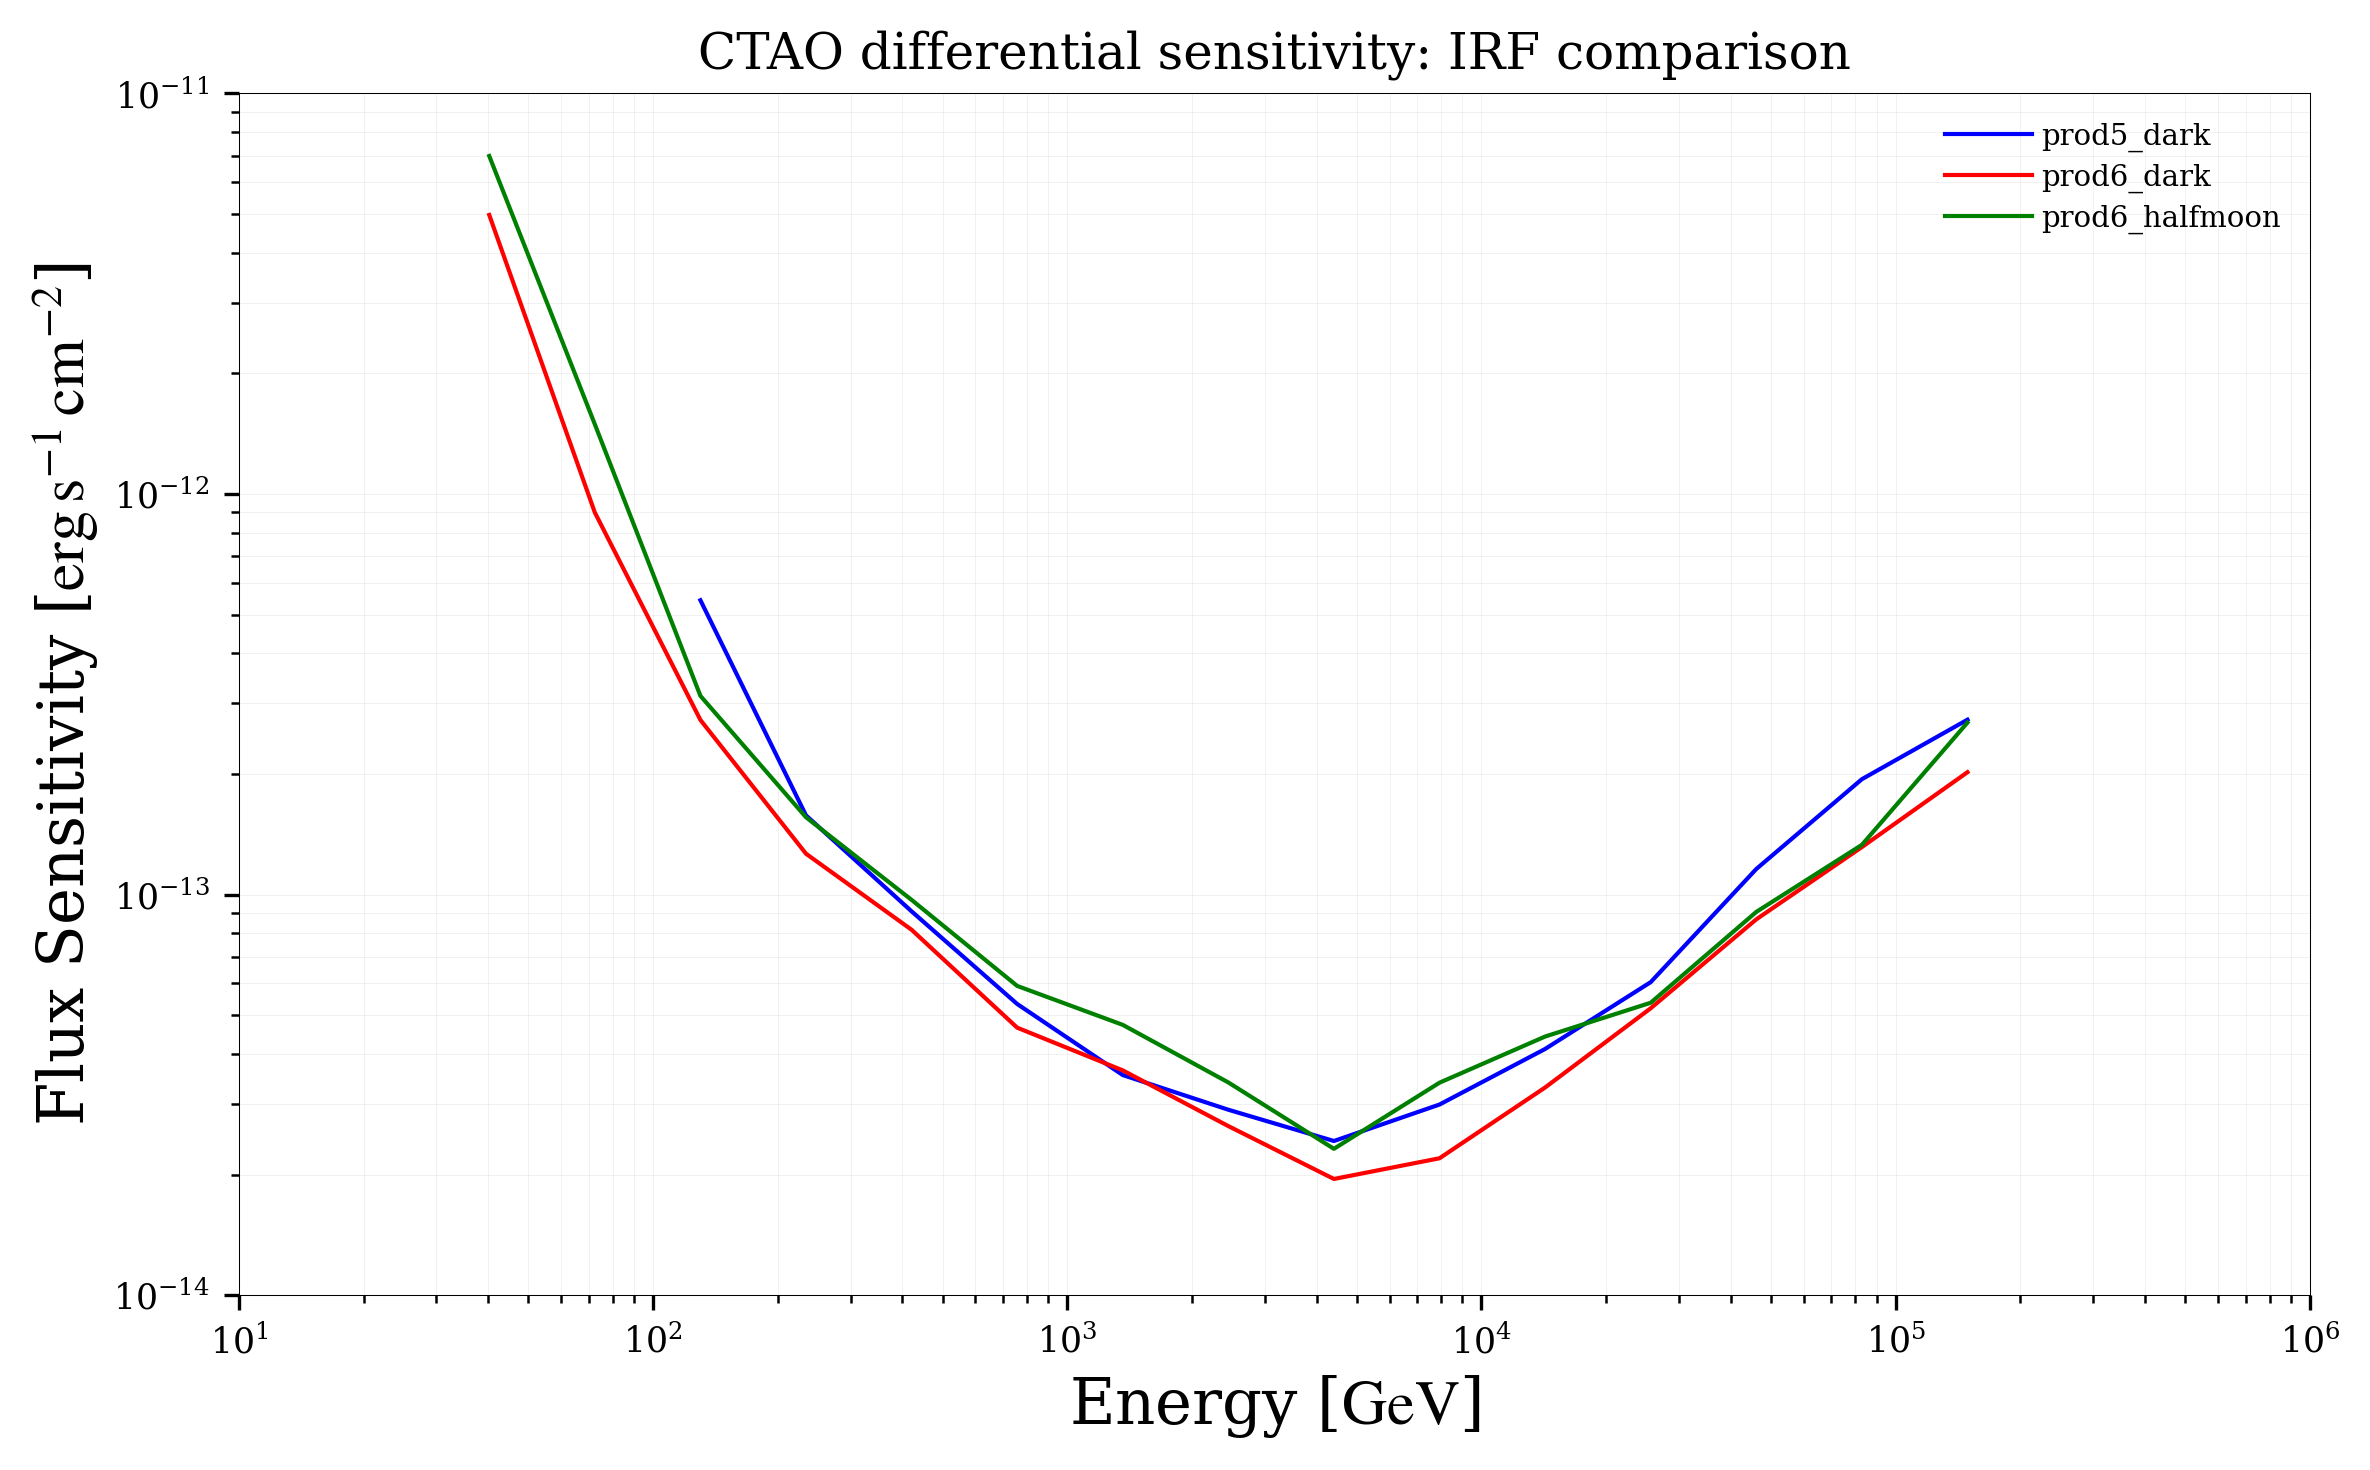

In [43]:
if tables:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_irfs(list(tables.values()), ax=ax, int_sens_label=False)
    ax.set_title("CTAO differential sensitivity: IRF comparison")
    ax.grid(alpha=0.2, which="both")
    plt.show()
else:
    print("No curves to plot. Calculate or load sensitivity tables first.")

## 9. Plot an individual curve

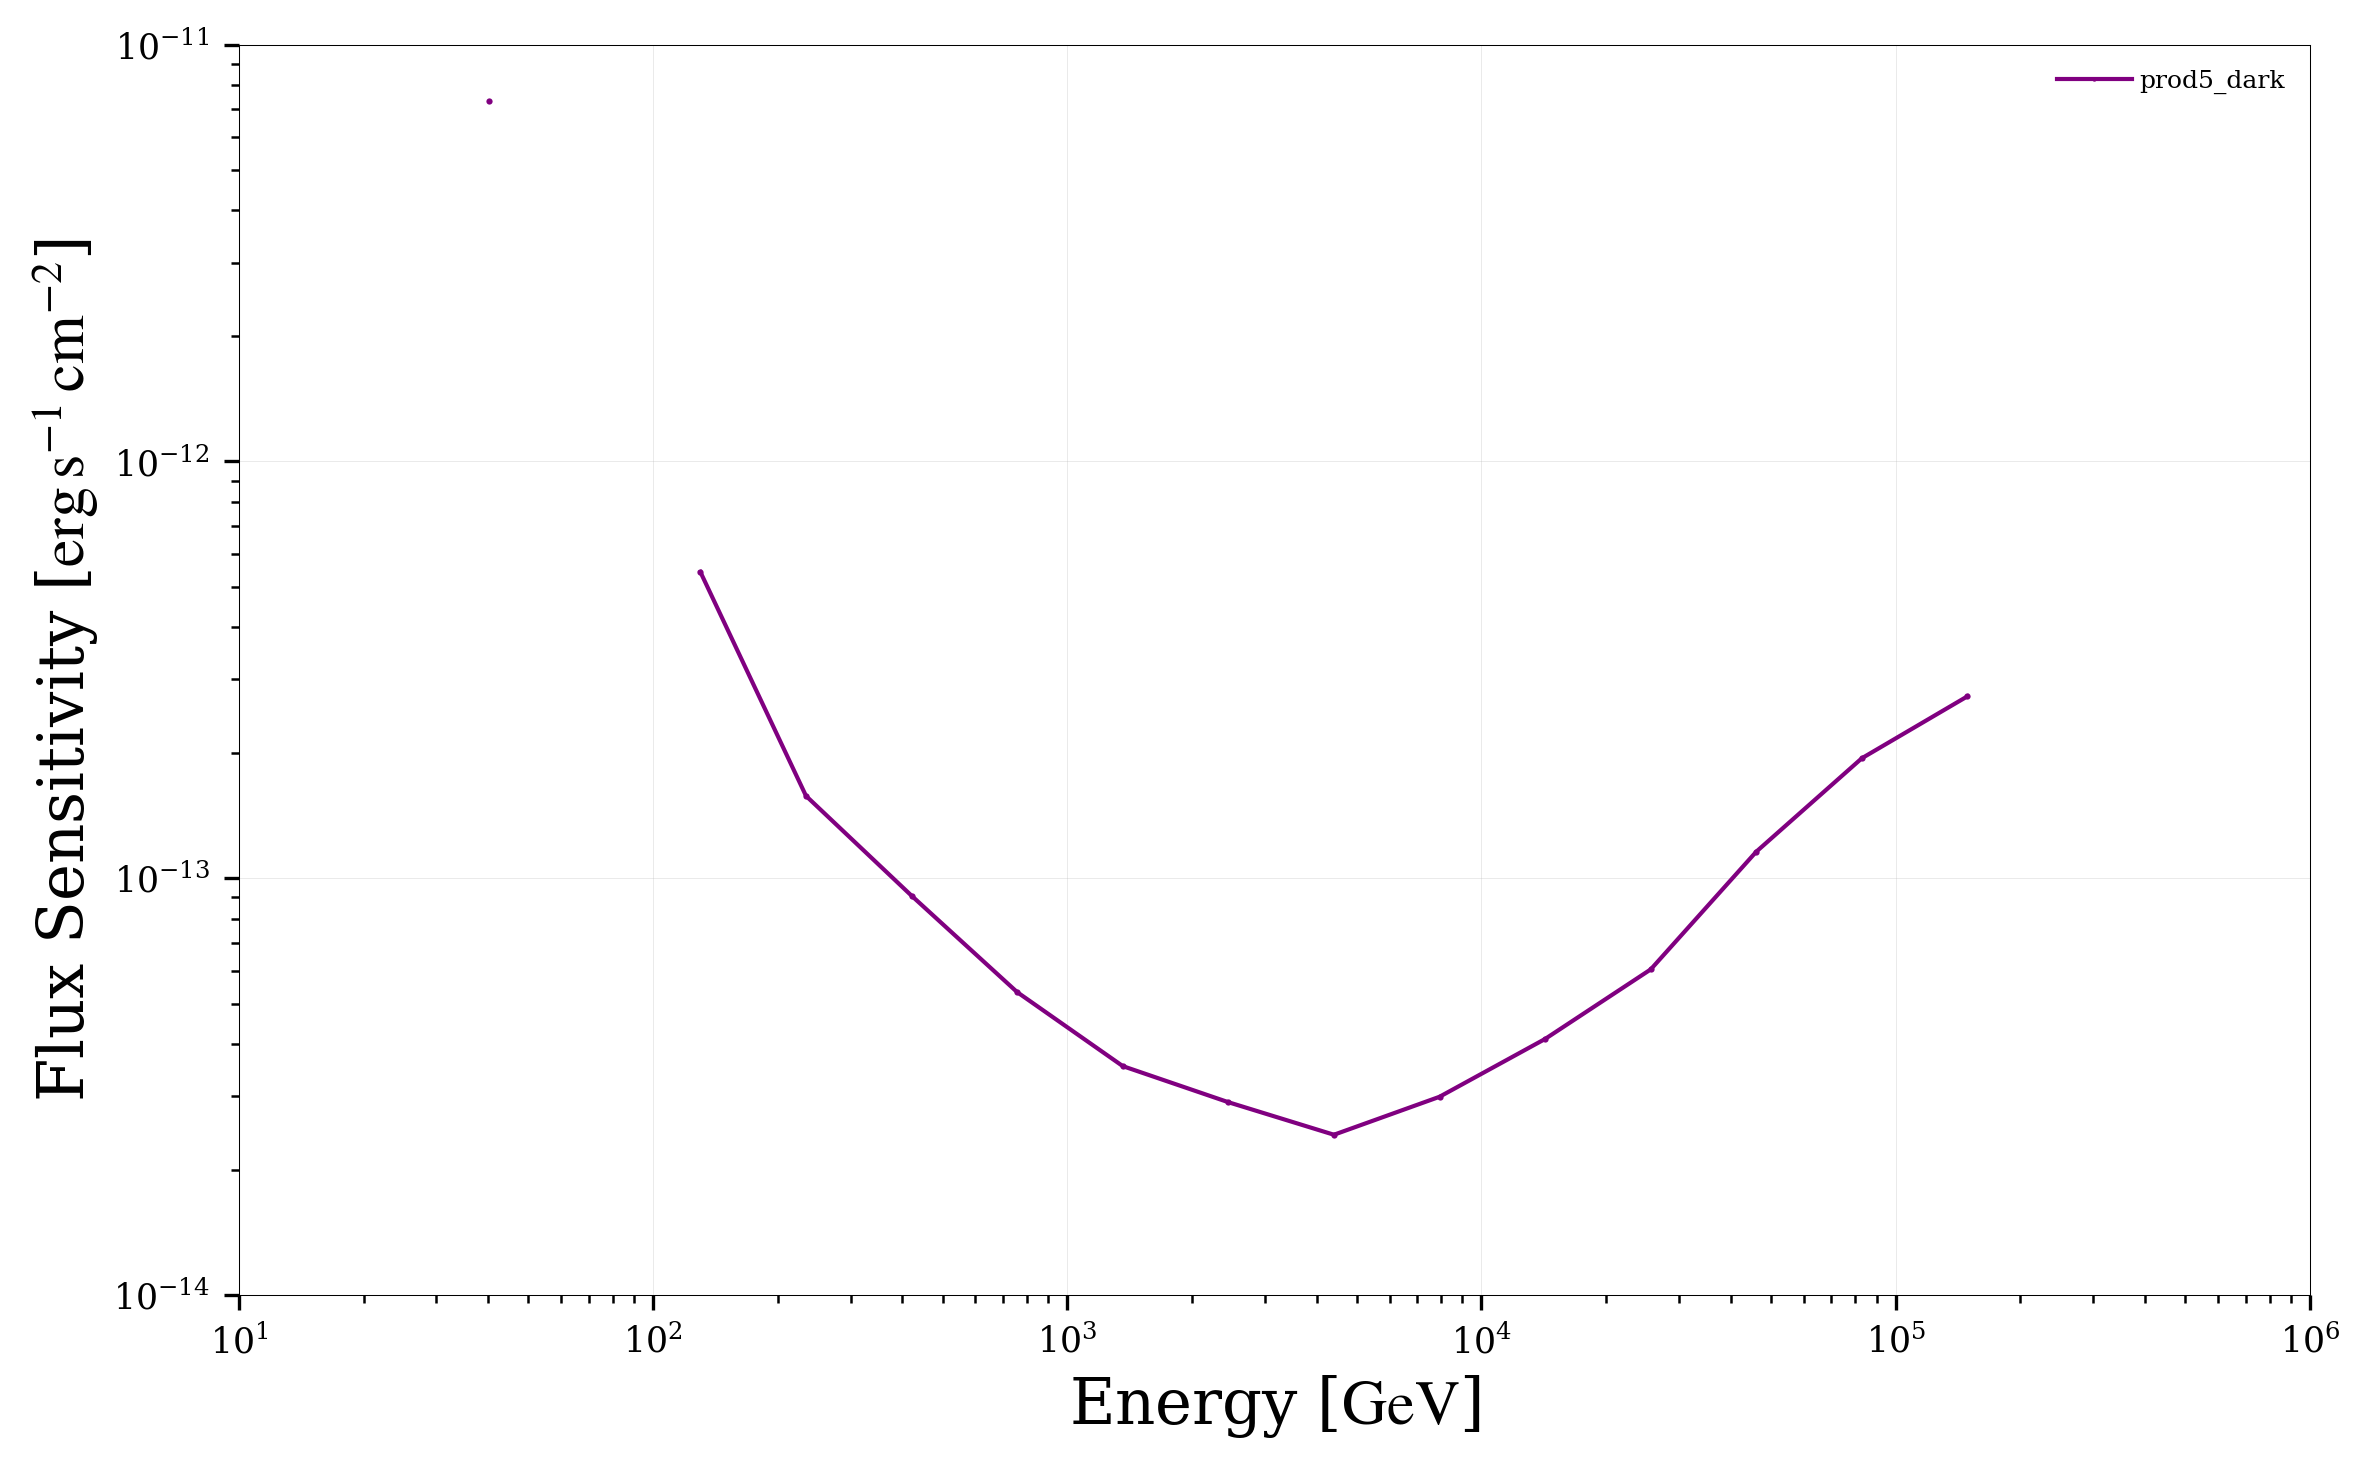

In [44]:
if tables:
    label, table = next(iter(tables.items()))
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_sensitivity_from_table(table, ax=ax, which="e2dnde", label=label)
    ax.legend(frameon=False)
    plt.show()

## 10. Create a complete FEUPY sensitivity figure

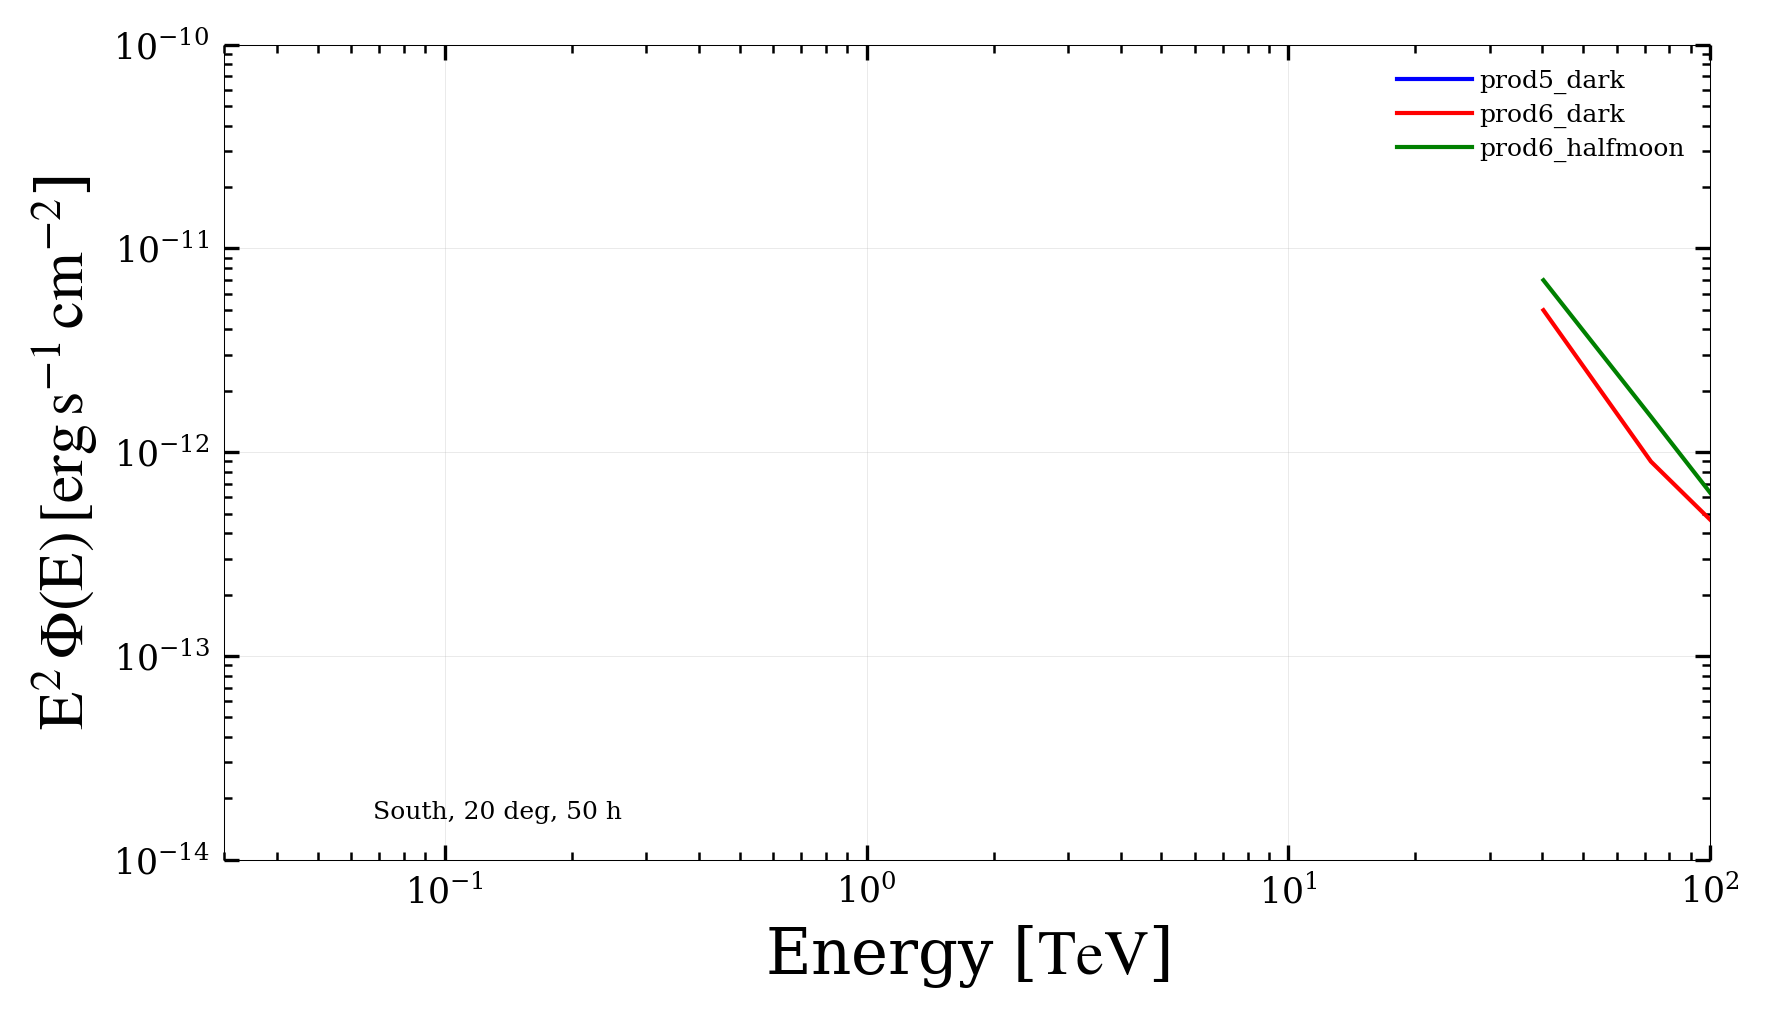

In [46]:
if tables:
    fig, ax = plot_tables_sensitivity(
        tables_south=list(tables.values()),
        #energy_bounds=u.Quantity([30, 100000], u.TeV),
        ylim=[1e-14, 1e-10],
        sens_info=f"{SITE}, {ZENITH_DEG} deg, {LIVETIME.to_value(u.h):g} h",
    )
    plt.show()

## 11. Interpretation and reproducibility

- **Production comparison:** prod5/dark vs prod6/dark may reflect changes in instrument assumptions and IRF generation, not merely observing conditions.
- **Moonlight comparison:** prod6/dark vs prod6/halfmoon isolates the observing-condition label more directly, provided all other settings and available IRFs match.
- **Methodology:** the sensitivity depends on the analysis cuts, binning, background acceptance, significance threshold, minimum gamma counts, and systematics.
- **Limitations:** the demonstration requires locally installed IRFs and valid FEUPY selectors. Saved tables are not bundled with this notebook. Ensure the assumed pointing geometry is appropriate for the chosen site/zenith configuration.

**Suggested output directory:** `data/sensitivity/<production>/<condition>/<site>_<zenith>deg_<livetime>h.ecsv`.